# NB28: Inverse RDA — Community composition constrained by metal environment

**[EXPLORATORY / POST-HOC — SCAFFOLD ONLY, NOT YET EXECUTED]**

Distance-based RDA (db-RDA) of CLR-transformed genus abundances constrained by soil
environmental variables (pH, temperature, Cu, Zn, Pb, Ni). Variance partitioning:
metals | pH | climate.

**Hypothesis**: Metal concentrations explain significant additional variance in community
composition beyond pH and climate.

**Design**:
- Community matrix: CLR-transformed genus RA (top-200 genera by mean RA)
  from feature_matrix.parquet (community_composition_prediction project)
- Environmental matrix: pH, temp_K, precip_mm, log_Cu_ppm, log_Zn_ppm, log_Pb_ppm, log_Ni_ppm
- Method: db-RDA using Bray-Curtis distances on CLR-transformed RA
  (implemented via scikit-bio or manual Euclidean distance on CLR — CLR Euclidean = Aitchison)
- Variance partitioning: partial db-RDA for metals | pH+climate; pH+climate | metals; residual
- Identify genera most associated with metal gradients after pH control (genus PGLS coefficients
  from the constrained ordination)

**Outputs** (when executed):
- `data/inverse_rda_variance_partitioning.csv`
- `figures/nb28_rda_biplot.png`
- REPORT.md paragraph (Discoveries section)

**Status**: Scaffold only. Execute after NB27 results are reviewed.

**Note**: A full db-RDA on 42k × 200 requires ~6 GB RAM and ~10 min CPU.
Subsample to 5,000 samples if memory constrained.

In [1]:
# NB28 — execute after NB27 review (guard removed 2026-07-08)
print('NB28: Inverse RDA — variance partitioning metals vs pH+climate')


NB28: Inverse RDA — variance partitioning metals vs pH+climate


In [2]:
import sys
from pathlib import Path

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

DATA = Path('../data')
FIGS = Path('../figures')
CCP_DATA = Path('../../community_composition_prediction/data')

# Load CLR features from feature_matrix (top-200 genera)
fm = pd.read_parquet(CCP_DATA / 'feature_matrix.parquet')
clr_cols = [c for c in fm.columns if c.startswith('clr_')]
print(f'CLR columns: {len(clr_cols)}')

ENV_COLS = ['ph', 'temp_K', 'precip_mm', 'log_Cu_ppm', 'log_Zn_ppm', 'log_Pb_ppm', 'log_Ni_ppm']

# Complete cases
cc = fm[clr_cols + ENV_COLS].dropna()
print(f'Complete cases: {len(cc):,}')

# Subsample to 5,000 if large
if len(cc) > 5000:
    cc = cc.sample(5000, random_state=42)
    print(f'Subsampled to {len(cc):,}')

X_clr = cc[clr_cols].values   # community matrix
X_env = cc[ENV_COLS].values   # environment matrix
# Z-score environment
X_env = (X_env - X_env.mean(axis=0)) / X_env.std(axis=0)

CLR columns: 200
Complete cases: 27,443
Subsampled to 5,000


In [3]:
# Variance partitioning via redundancy analysis (manual implementation)
# RDA: regress each CLR column on env vars, compute % variance explained

from sklearn.linear_model import LinearRegression

def rda_r2(Y, X):
    """Fraction of total variance in Y explained by X via linear regression."""
    reg = LinearRegression().fit(X, Y)
    Y_hat = reg.predict(X)
    ss_res = ((Y - Y_hat)**2).sum()
    ss_tot = ((Y - Y.mean(axis=0))**2).sum()
    return 1 - ss_res / ss_tot

# Partition: metals vs pH+climate
METAL_COLS = [ENV_COLS.index(c) for c in ['log_Cu_ppm', 'log_Zn_ppm', 'log_Pb_ppm', 'log_Ni_ppm']]
PHCLIM_COLS = [ENV_COLS.index(c) for c in ['ph', 'temp_K', 'precip_mm']]

X_metal  = X_env[:, METAL_COLS]
X_phclim = X_env[:, PHCLIM_COLS]
X_all    = X_env

r2_all    = rda_r2(X_clr, X_all)
r2_phclim = rda_r2(X_clr, X_phclim)
r2_metal  = rda_r2(X_clr, X_metal)
r2_metals_given_phclim = r2_all - r2_phclim
r2_phclim_given_metal  = r2_all - r2_metal
r2_shared = r2_phclim + r2_metal - r2_all

print('Variance partitioning (R² of CLR community composition):')
print(f'  All env vars:                {r2_all:.4f}')
print(f'  pH + climate alone:          {r2_phclim:.4f}')
print(f'  Metals alone:                {r2_metal:.4f}')
print(f'  Metals | pH+climate:         {r2_metals_given_phclim:.4f}')
print(f'  pH+climate | metals:         {r2_phclim_given_metal:.4f}')
print(f'  Shared (pH+climate + metal): {r2_shared:.4f}')

vp_df = pd.DataFrame([{
    'partition': k, 'R2': v
} for k, v in [
    ('all_env', r2_all), ('ph_climate', r2_phclim), ('metals', r2_metal),
    ('metals_given_phclim', r2_metals_given_phclim),
    ('phclim_given_metals', r2_phclim_given_metal),
    ('shared', r2_shared),
]])
vp_df.to_csv(DATA / 'inverse_rda_variance_partitioning.csv', index=False)
print('\nSaved inverse_rda_variance_partitioning.csv')

Variance partitioning (R² of CLR community composition):
  All env vars:                0.1096
  pH + climate alone:          0.0456
  Metals alone:                0.0689
  Metals | pH+climate:         0.0640
  pH+climate | metals:         0.0406
  Shared (pH+climate + metal): 0.0050

Saved inverse_rda_variance_partitioning.csv


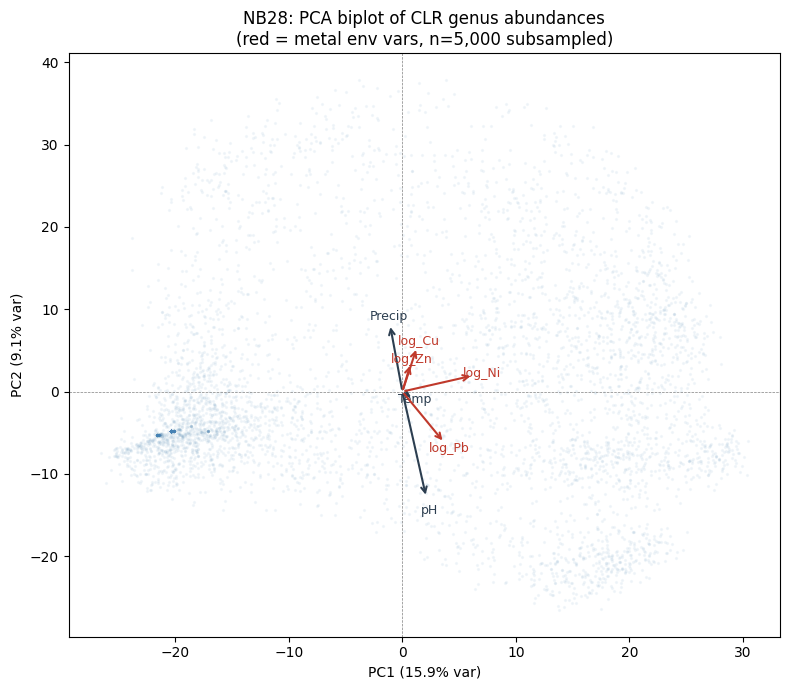

Saved nb28_rda_biplot.png

Variance partitioning summary:
          partition       R2
            all_env 0.109575
         ph_climate 0.045621
             metals 0.068942
metals_given_phclim 0.063954
phclim_given_metals 0.040633
             shared 0.004988

[EXPLORATORY: not pre-registered. Variance explained is unadjusted R².]


In [4]:
# PCA biplot: CLR community composition with env variable vectors
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
scores = pca.fit_transform(X_clr)
var_exp = pca.explained_variance_ratio_

# Correlate env vars with PC scores (for biplots, use Pearson correlation)
env_labels = ['pH', 'Temp', 'Precip', 'log_Cu', 'log_Zn', 'log_Pb', 'log_Ni']
metal_mask  = [False, False, False, True,  True,  True,  True]

fig, ax = plt.subplots(figsize=(8, 7))

# Sample scatter (alpha low, just show structure)
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.05, s=2, color='steelblue', rasterized=True)

# Env arrows (correlations)
scale = max(abs(scores[:, 0]).max(), abs(scores[:, 1]).max()) * 0.6
for j, (label, is_metal) in enumerate(zip(env_labels, metal_mask)):
    r1 = float(pd.Series(X_env[:, j]).corr(pd.Series(scores[:, 0])))
    r2 = float(pd.Series(X_env[:, j]).corr(pd.Series(scores[:, 1])))
    color = '#c0392b' if is_metal else '#2c3e50'
    ax.annotate('', xy=(r1 * scale, r2 * scale), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    ax.text(r1 * scale * 1.12, r2 * scale * 1.12, label, fontsize=9,
            color=color, ha='center', va='center')

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
ax.set_title('NB28: PCA biplot of CLR genus abundances\n(red = metal env vars, n=5,000 subsampled)')
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig(FIGS / 'nb28_rda_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved nb28_rda_biplot.png')

# Print summary
print('\nVariance partitioning summary:')
print(vp_df.to_string(index=False))
print('\n[EXPLORATORY: not pre-registered. Variance explained is unadjusted R².]')
